In [153]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [ ]:

k = symbols('k', positive=True, real=True)
l = symbols('ell', positive=True, real=True)

_b = symbols('b', positive=True, real=True)
b = symbols('beta', positive=True, real=True)

A = symbols('A', positive=True, real=True)

H = symbols('H', positive=True, real=True)

B = symbols('B', positive=True, real=True)

D = symbols('D', positive=True, integer=True)


In [174]:

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD.simplify())

CD = integrate(ftD, (l, 0, oo))
#display(CD.simplify())
CD = CD.simplify().args[0][0]
display(CD)

acfD = exp(-A * l)

OD = S(2)*pi**(D/S(2))/gamma(D/S(2))
ED = (OD**2/(2*pi)**D) * integrate(acfD * ftD * (k*l)**(D-1), (l, 0, oo))
display(ED.simplify())

eq_ED = (B/_b) * S(1)/S(2) * l**2 * diff(2 * (S(1) - acfD), l)
display(eq_ED.simplify())
eq_EDs = eq_ED.subs({l: _b/k})
display(eq_EDs.simplify())

L1 = integrate(acfD, (l, 0, oo))
L2 = integrate(ED * CD, (k, 0, oo))
L3 = integrate(eq_EDs * CD, (k, 0, oo))

display(L1.simplify())
display(L2.simplify())
display(L3.simplify())

#display(L3.subs({B: S(1)/BIAS.subs({b: S(2)}).simplify(), b: S(1)}).simplify())


2**(D/2 - 1)*(ell*k)**(1 - D/2)*besselj(D/2 - 1, ell*k)*gamma(D/2)

sqrt(pi)*gamma(D/2)/(k*gamma(D/2 - 1/2))

2*A*k**(D - 1)*(A**2 + k**2)**(-D/2 - 1/2)*gamma(D/2 + 1/2)/(sqrt(pi)*gamma(D/2))

A*B*ell**2*exp(-A*ell)/b

A*B*b*exp(-A*b/k)/k**2

1/A

Piecewise((1/A, D > 1), (2*A*gamma(D/2 + 1/2)*Integral(k**(D - 2)*(A**2 + k**2)**(-D/2 - 1/2), (k, 0, oo))/gamma(D/2 - 1/2), True))

sqrt(pi)*B*gamma(D/2)/(A*b*gamma(D/2 - 1/2))

In [148]:

k = symbols('k', positive=True, real=True)
l = symbols('ell', positive=True, real=True)

b = symbols('beta', positive=True, real=True)

A = symbols('A', positive=True, real=True)


H = symbols('H', positive=True, real=True)


ED = (S(2)/pi) * (A**S(2) / (A**S(2) + k**S(2)))**(b/S(2))
#ED = (S(4)/pi) * (A**2 * k**2 / (A**2 + k**2)**2)
display(ED.simplify())

D = symbols('D', positive=True, integer=True)
D = S(3)
ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD.simplify())

R = integrate(ftD * ED, (k, 0, oo))
display(R.simplify().subs({b: S(2)}).expand(func=True).simplify())

eq_ED = S(1)/S(2) * l**2 * diff(2 * integrate((S(1)-ftD)*ED, (k, 0, oo)), l)
eq_ED = eq_ED.simplify().args[0][0]#.subs({b: S(1) + S(2)*H}).simplify()
display(eq_ED.simplify())

eq_ED_s = eq_ED.subs({b: S(1) + S(2)*H}).simplify()#.expand(func=True).simplify()

display(eq_ED_s)

#display(eq_ED_s.subs({D: S(1)}).simplify().expand(func=True).simplify())
#display(eq_ED_s.subs({D: S(2), H: Rational(1,2), A: S(1)}).simplify().expand(func=True).simplify())
#display(eq_ED_s.subs({H: Rational(1,2)}).simplify())
display(eq_ED_s.subs({H: Rational(1,2), A: S(1)}).simplify().expand(func=True).simplify())


2*(A/sqrt(A**2 + k**2))**beta/pi

sin(ell*k)/(ell*k)

(1 - exp(-A*ell))/ell

2**(-beta/2 - 1/2)*sqrt(A)*sqrt(ell)*(2**(beta/2)*meijerg(((3/4,), ()), ((beta/2 - 1/4, 1/4), (-1/4,)), A**2*ell**2/4)*cos(pi*beta/2) + 2*pi*A**(beta/2)*ell**(beta/2)*besseli(1/2 - beta/2, A*ell) - 2*pi*A**(beta/2)*ell**(beta/2)*besseli(beta/2 - 1/2, A*ell))/(sqrt(pi)*cos(pi*beta/2)*gamma(beta/2))

2**(-H - 1)*(2**(H + 1/2)*sqrt(A)*sqrt(ell)*meijerg(((3/4,), ()), ((H + 1/4, 1/4), (-1/4,)), A**2*ell**2/4)*sin(pi*H) - 2*pi*(A*ell)**(H + 1)*besseli(-H, A*ell) + 2*pi*(A*ell)**(H + 1)*besseli(H, A*ell))/(sqrt(pi)*sin(pi*H)*gamma(H + 1/2))

ell*sinh(ell) - ell*cosh(ell) + sinh(ell) - cosh(ell) + 1

In [149]:

spec = ED.subs({b: S(1) + S(2)*H}).subs({H: Rational(1,2)})
display(spec)

func = eq_ED_s.subs({H: Rational(1,2)}).simplify()
display(func)
terms = func.args

_l = 10.**(np.linspace(np.log10(1e-5), np.log10(10.), 1000))
eqs = [np.zeros_like(_l) for _ in range(len(terms))]

t_eq = np.zeros_like(_l)

s_eq = np.zeros_like(_l)

for i, __l in enumerate(_l):
    for j, t in enumerate(terms):
        val = t.subs({A: S(1), l: __l})
        eqs[j][i] = val
        val = func.subs({A: S(1), l: __l})
        t_eq[i] = val
        val = spec.subs({A: S(1), k: 1./__l})
        s_eq[i] = val


2*A**2/(pi*(A**2 + k**2))

A*ell*sinh(A*ell) - A*ell*cosh(A*ell) + sinh(A*ell) - cosh(A*ell) + 1

(1 - exp(-A*ell))/ell

oo

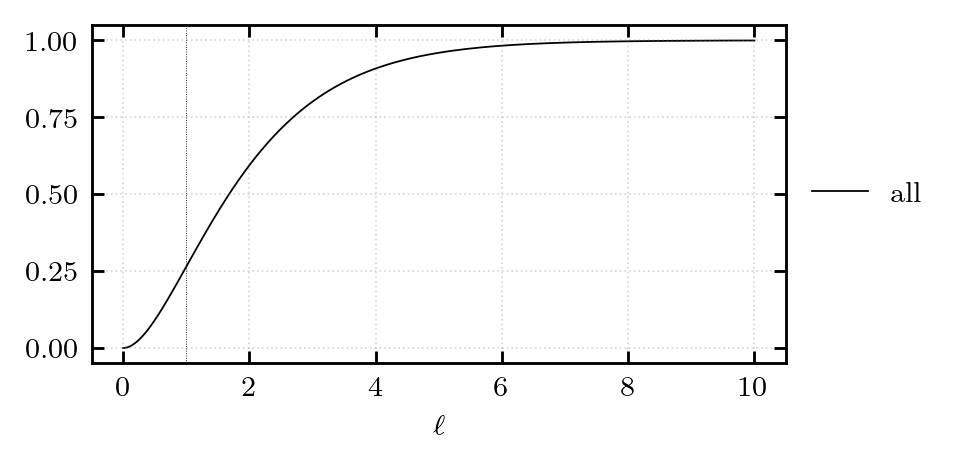

In [152]:

Rs = R.simplify().subs({b: S(2)}).simplify()
display(Rs)
L = integrate(Rs, (l, 0, oo))
display(L)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

eqs = np.zeros_like(_l)

for i, __l in enumerate(_l):
    eqs[i] = Rs.subs({l: __l, A: S(1)}).evalf()

ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label='all', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)
#ax.axhline(1./np.exp(1.), linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#ax.set_xscale('log')
#ax.set_ylim((-10, 10))
#ax.set_xlim((1e-1, 1e1))

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


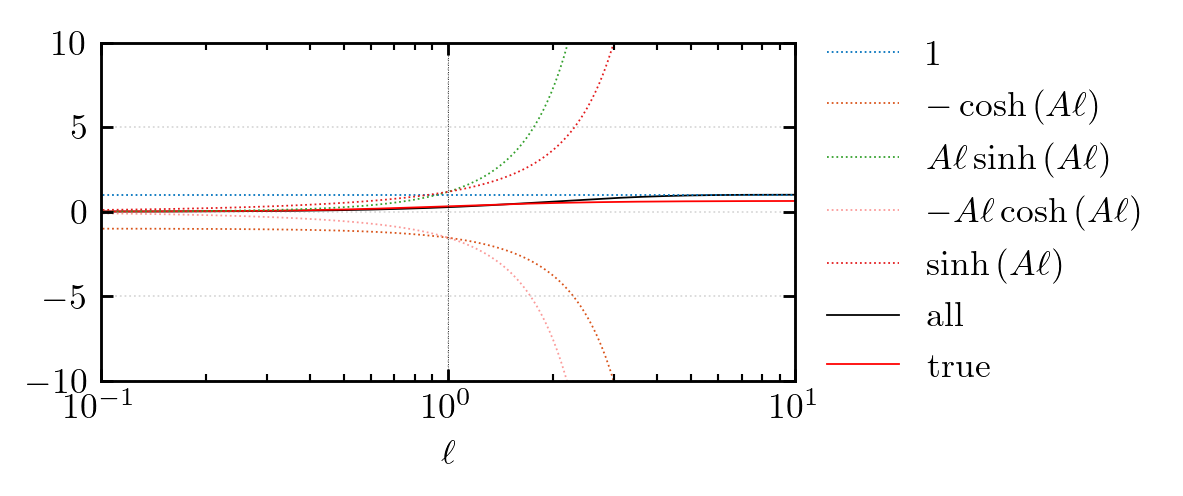

In [54]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

for i, t in enumerate(terms):
    ax.plot(_l, eqs[i], linestyle=':', color=c[i], linewidth=0.5, label=r'$%s$' % latex(t), zorder=1)
ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label='all', zorder=0)
ax.plot(_l, s_eq, linestyle='-', color='red', linewidth=0.5, label='true', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_xscale('log')
ax.set_ylim((-10, 10))
ax.set_xlim((1e-1, 1e1))

ax.set_xlabel(r'$\ell$')

# ax.set_ylim((3e-4, 8e-1))
# ax.set_xlim((0.3, 110))

#ax.legend(loc='lower left')
ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


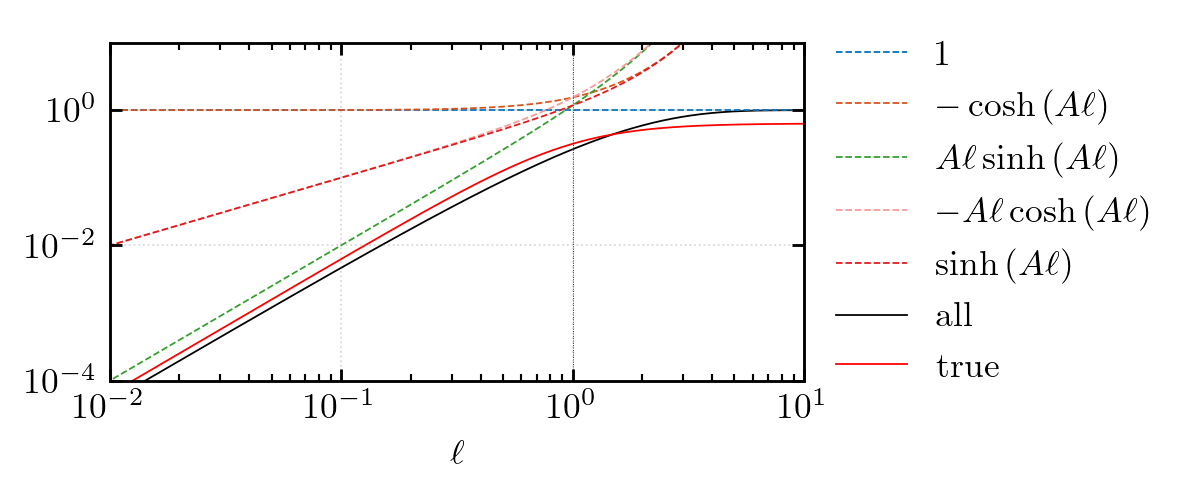

In [79]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

for i, t in enumerate(terms):
    ax.plot(_l, abs(eqs[i]), linestyle='--', color=c[i], linewidth=0.5, label=r'$%s$' % latex(t), zorder=1)
ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label='all', zorder=0)
ax.plot(_l, s_eq, linestyle='-', color='red', linewidth=0.5, label='true', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((1e-4, 1e1))
ax.set_xlim((1e-2, 1e1))

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


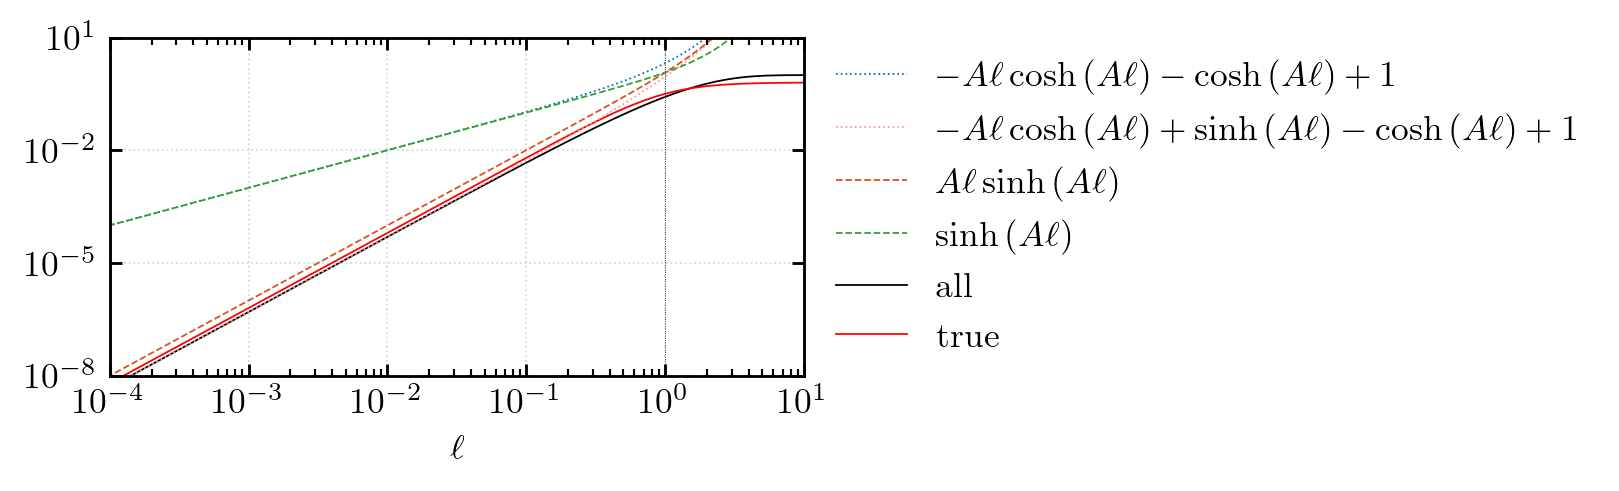

In [98]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, abs(eqs[0]+eqs[1]+eqs[3]), linestyle=':', color=c[0], linewidth=0.5, label=r'$%s$' % latex(terms[0]+terms[1]+terms[3]), zorder=1)
ax.plot(_l, abs(eqs[0]+eqs[4]+eqs[1]+eqs[3]), linestyle=':', color=c[3], linewidth=0.5, label=r'$%s$' % latex(terms[0]+terms[4]+terms[1]+terms[3]), zorder=1)
ax.plot(_l, eqs[2], linestyle='--', color=c[1], linewidth=0.5, label=r'$%s$' % latex(terms[2]), zorder=1)
ax.plot(_l, eqs[4], linestyle='--', color=c[2], linewidth=0.5, label=r'$%s$' % latex(terms[4]), zorder=1)

ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label='all', zorder=0)
ax.plot(_l, s_eq, linestyle='-', color='red', linewidth=0.5, label='true', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((1e-8, 1e1))
ax.set_xlim((1e-4, 1e1))

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


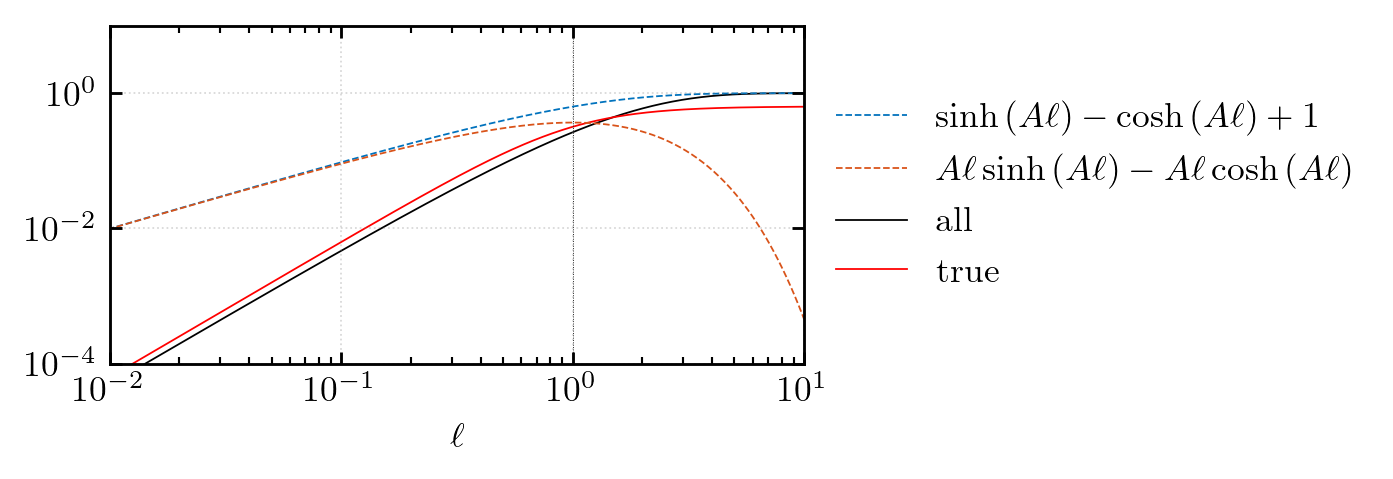

In [87]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, eqs[0]+eqs[1]+eqs[4], linestyle='--', color=c[0], linewidth=0.5, label=r'$%s$' % latex(terms[0]+terms[1]+terms[4]), zorder=1)
ax.plot(_l, abs(eqs[2]+eqs[3]), linestyle='--', color=c[1], linewidth=0.5, label=r'$%s$' % latex(terms[2]+terms[3]), zorder=1)

ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label='all', zorder=0)
ax.plot(_l, s_eq, linestyle='-', color='red', linewidth=0.5, label='true', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((1e-4, 1e1))
ax.set_xlim((1e-2, 1e1))

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


In [111]:

e_ts = []

for t in terms:
    #s_t = Limit(t, l, A)
    #display(s_t.simplify())
    e_t = series(t, l, 0, 3).expand()
    display(e_t.simplify())
    e_ts.append(e_t)


1

-1 - A**2*ell**2/2 + O(ell**3)

A**2*ell**2 + O(ell**3)

-A*ell + O(ell**3)

A*ell + O(ell**3)

In [112]:

e_A = e_ts[0]+e_ts[1]+e_ts[3]+e_ts[4]
e_B = e_ts[2]

display(e_A.simplify())
display(e_B.simplify())

display((e_A+e_B).simplify())


-A**2*ell**2/2 + O(ell**3)

A**2*ell**2 + O(ell**3)

A**2*ell**2/2 + O(ell**3)

In [113]:

for t in terms:
    d_t = l * diff(ln(t), l)
    display(d_t.simplify())
    l_t = limit(d_t, l, 0)
    display(l_t.simplify())


0

0

A*ell*tanh(A*ell)

0

A*ell/tanh(A*ell) + 1

2

A*ell*tanh(A*ell) + 1

1

A*ell/tanh(A*ell)

1

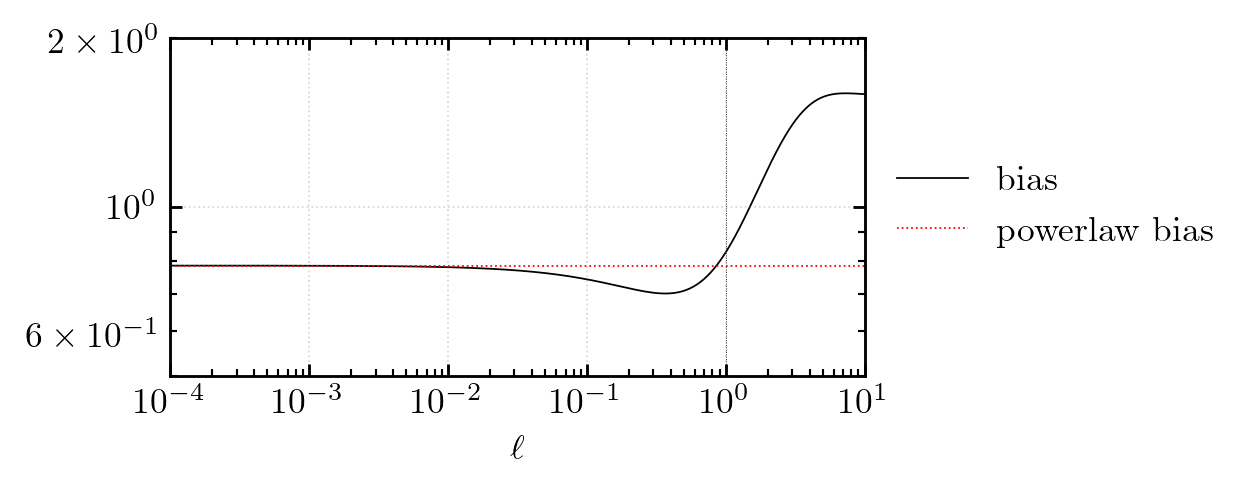

In [121]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, t_eq/s_eq, linestyle='-', color='black', linewidth=0.5, label='bias', zorder=0)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

bias = S(2)**(S(1)-b) * gamma(D/S(2))*gamma(Rational(3,2)-b/S(2)) / gamma(D/S(2) + b/S(2) - Rational(1,2))
__b = bias.subs({b: S(2), D: S(3)})

ax.axhline(__b, linestyle=':', color='red', linewidth=0.5, zorder=0, label='powerlaw bias')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((5e-1, 2))
ax.set_xlim((1e-4, 1e1))

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)

